In [2]:
import torch
import numpy as np
from marchingband_data.run_sim import generate_training_data, system_regimes_gt
from marchingband_data.metrics import compute_regime_labeling_accuracy, get_aligned_estimate
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from dsarf import DSARF


### MarchingBand Dataset

In [6]:
N = 10
J = 64
total_time = 10300
T = 200
D = 2
L = [list(range(1, i + 1)) for i in [200]][0]
factor_dim = 25
seed = 120
true_system_regimes = np.argmax(system_regimes_gt(10,  [1227, 2840, 6128, 7392, 9553, 9680]), axis=1)
GLOBAL_MSG = "LAUGH" * N
total_data = generate_training_data(GLOBAL_MSG, J, T, 0)
data = total_data[0]
end_times = [0, 1000, 2050, 3100, 4100, 5100, 6100, 7150, 8200, 9200, 10300]
data = data.reshape(total_time, J*D)
segments = []
for i in range(len(end_times) - 1):
    start = end_times[i]
    end = end_times[i+1]
    segment = data[start:end] 
    segments.append(segment)

Running simulation for 12500 steps, recording every 5th step


### Case 1: Concatenation for System-State Classification 

In [7]:
# Create and train the model
torch.manual_seed(seed)
dsarf = DSARF(J * D, factor_dim=factor_dim, L=L, S=6, batch_size=1)
model = dsarf.fit(segments, epoch_num=200)
model_train = model[0]
loss = model[1]
stats = model_train.report_stats(segments)

# Extract posterior summary, losses, prediction stats
posterior_summary = model_train.q_s

Using device: cpu
Total Number of Parameters: 3081137
Learnable Parameters: 3015137


  0%|          | 0/200 [00:00<?, ?it/s]

### Get System-State Classification Accuracy

In [8]:
end_times = [1000, 1050, 1050, 1000, 1000, 1000, 1050, 1050, 1000, 1100]
new_summary = []
for v,z in zip(posterior_summary, end_times): 
    k = v[:z]
    new_summary.append(k)
estimated_regimes = np.argmax(np.vstack(new_summary), axis = 1)
pct_correct_system = compute_regime_labeling_accuracy(estimated_regimes, true_system_regimes)
print(pct_correct_system)

0.3312621359223301


### Plot Ground Truth System State Classification

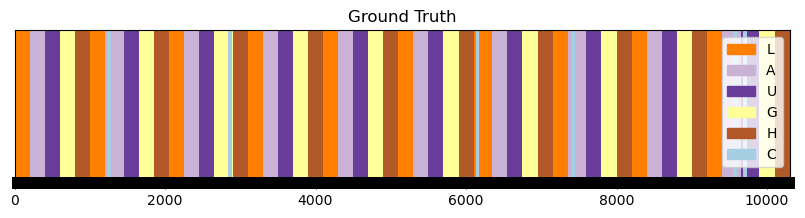

In [9]:
letters=["L", "A", "U", "G", "H", "C"]
colors=['#ff7f00','#cab2d6','#6a3d9a','#ffff99','#b15928','#a6cee3']

unique_values = np.unique(true_system_regimes)
    
if len(unique_values) > len(colors):
    raise ValueError("More unique values than colors available. Please provide additional colors.")

color_map = dict(zip(unique_values, colors[:len(unique_values)]))
letter_map = dict(zip(unique_values, letters[:len(unique_values)]))
    
fig, ax = plt.subplots(figsize=(10, 2))

for i, value in enumerate(true_system_regimes):
    # Draw the rectangle segment
    rect = patches.Rectangle((i, -1), 1, 2, linewidth=0, edgecolor='none', facecolor=color_map[value])
    ax.add_patch(rect)
    # Add text to the middle of the rectangle
    ax.text(i + 0.5, 0, letter_map[value], ha='center', va='center', fontsize=12, color='black')

# Customize plot
ax.set_xlim(0, len(true_system_regimes))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_title('Ground Truth')

# Add a legend
handles = [patches.Patch(color=color_map[val], label=f'{letter_map[val]}') for val in unique_values]
ax.legend(handles=handles, loc='upper right')
plt.show()

### Plot Model System State Classification

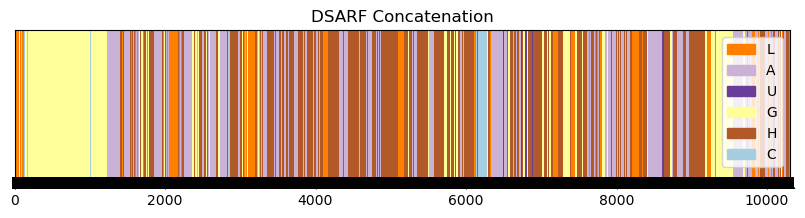

In [10]:
end_times = [1000, 1050, 1050, 1000, 1000, 1000, 1050, 1050, 1000, 1100]
new_summary = []
for v,z in zip(posterior_summary, end_times): 
    k = v[:z]
    new_summary.append(k)
estimated_regimes = np.argmax(np.vstack(new_summary), axis = 1)
aligned_matrix = get_aligned_estimate(estimated_regimes, true_system_regimes)
segment_matrix = aligned_matrix.reshape(1, -1)
segment_matrix  = segment_matrix[0]

letters=["L", "A", "U", "G", "H", "C"]
colors=['#ff7f00','#cab2d6','#6a3d9a','#ffff99','#b15928','#a6cee3']

unique_values = np.unique(segment_matrix)
    
if len(unique_values) > len(colors):
    raise ValueError("More unique values than colors available. Please provide additional colors.")

color_map = dict(zip(unique_values, colors[:len(unique_values)]))
letter_map = dict(zip(unique_values, letters[:len(unique_values)]))
    
fig, ax = plt.subplots(figsize=(10, 2))

for i, value in enumerate(segment_matrix):
    # Draw the rectangle segment
    rect = patches.Rectangle((i, -1), 1, 2, linewidth=0, edgecolor='none', facecolor=color_map[value])
    ax.add_patch(rect)
    # Add text to the middle of the rectangle
    ax.text(i + 0.5, 0, letter_map[value], ha='center', va='center', fontsize=12, color='black')

# Customize plot
ax.set_xlim(0, len(segment_matrix))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_title('DSARF Concatenation')

# Add a legend
handles = [patches.Patch(color=color_map[val], label=f'{letter_map[val]}') for val in unique_values]
ax.legend(handles=handles, loc='upper right')
plt.show()